# 01 - Exploratory Data Analysis: Enron-Spam

Four sections:
1. **Class balance** - overall and per-subset
2. **Text length distribution** - characters and words by class
3. **Top words per class** - most frequent stemmed tokens
4. **Word clouds** - visual summary of ham vs spam vocabulary

All figures are saved to `reports/`.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=UserWarning)

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

REPORTS_DIR = repo_root / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight'})
print(f'Reports -> {REPORTS_DIR}')

Reports -> C:\Users\akshi\Desktop\spam email\email-spam-classifier\reports


In [2]:
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s  %(message)s')

from src.data_loader import load_enron_spam

df = load_enron_spam()
print(f'Loaded {len(df):,} emails | columns: {list(df.columns)}')
df.head(3)

INFO  Loaded from cache: C:\Users\akshi\Desktop\spam email\email-spam-classifier\data\processed\enron_spam.csv


Loaded 33,716 emails | columns: ['text', 'label', 'source']


,text,label,source
0,Subject: christmas tree farm pictures\n,0,enron1
1,"Subject: vastar resources , inc .\ngary , prod...",0,enron1
2,Subject: calpine daily gas nomination\n- calpi...,0,enron1


## 1. Class Balance

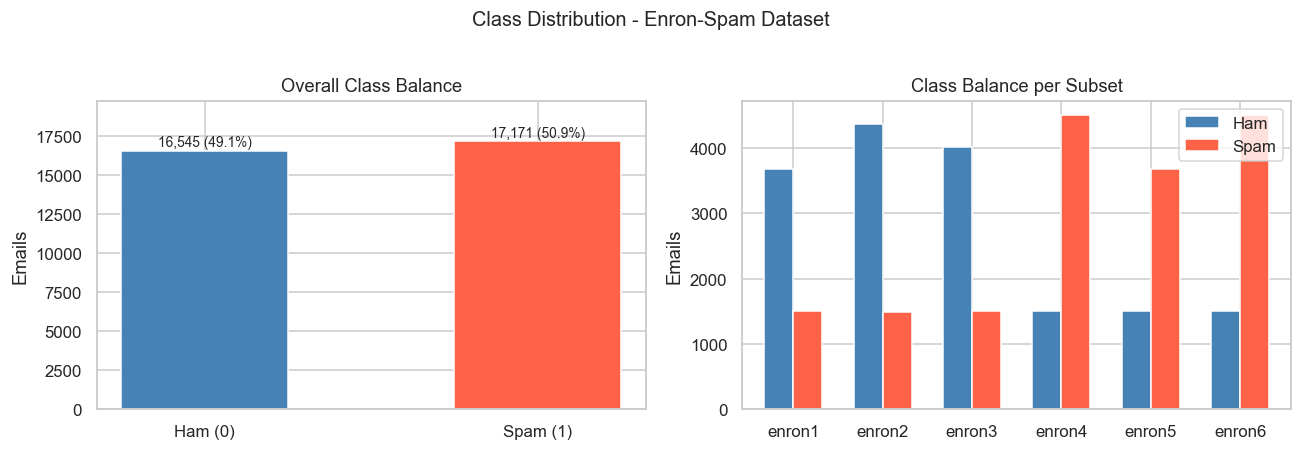

Saved -> reports/eda_class_balance.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts().sort_index()
bars = axes[0].bar(['Ham (0)', 'Spam (1)'], counts.values,
                   color=['steelblue', 'tomato'], width=0.5)
for bar, v in zip(bars, counts.values):
    label_str = f'{v:,} ({v/len(df):.1%})'
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 80,
                 label_str, ha='center', va='bottom', fontsize=9)
axes[0].set_title('Overall Class Balance')
axes[0].set_ylabel('Emails')
axes[0].set_ylim(0, counts.max() * 1.15)

pivot = df.groupby(['source', 'label']).size().unstack(fill_value=0)
pivot.columns = ['Ham', 'Spam']
pivot.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], width=0.65)
axes[1].set_title('Class Balance per Subset')
axes[1].set_xlabel('')
axes[1].set_ylabel('Emails')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.suptitle('Class Distribution - Enron-Spam Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_class_balance.png')
plt.show()
plt.close()
print('Saved -> reports/eda_class_balance.png')

## 2. Text Length Distribution

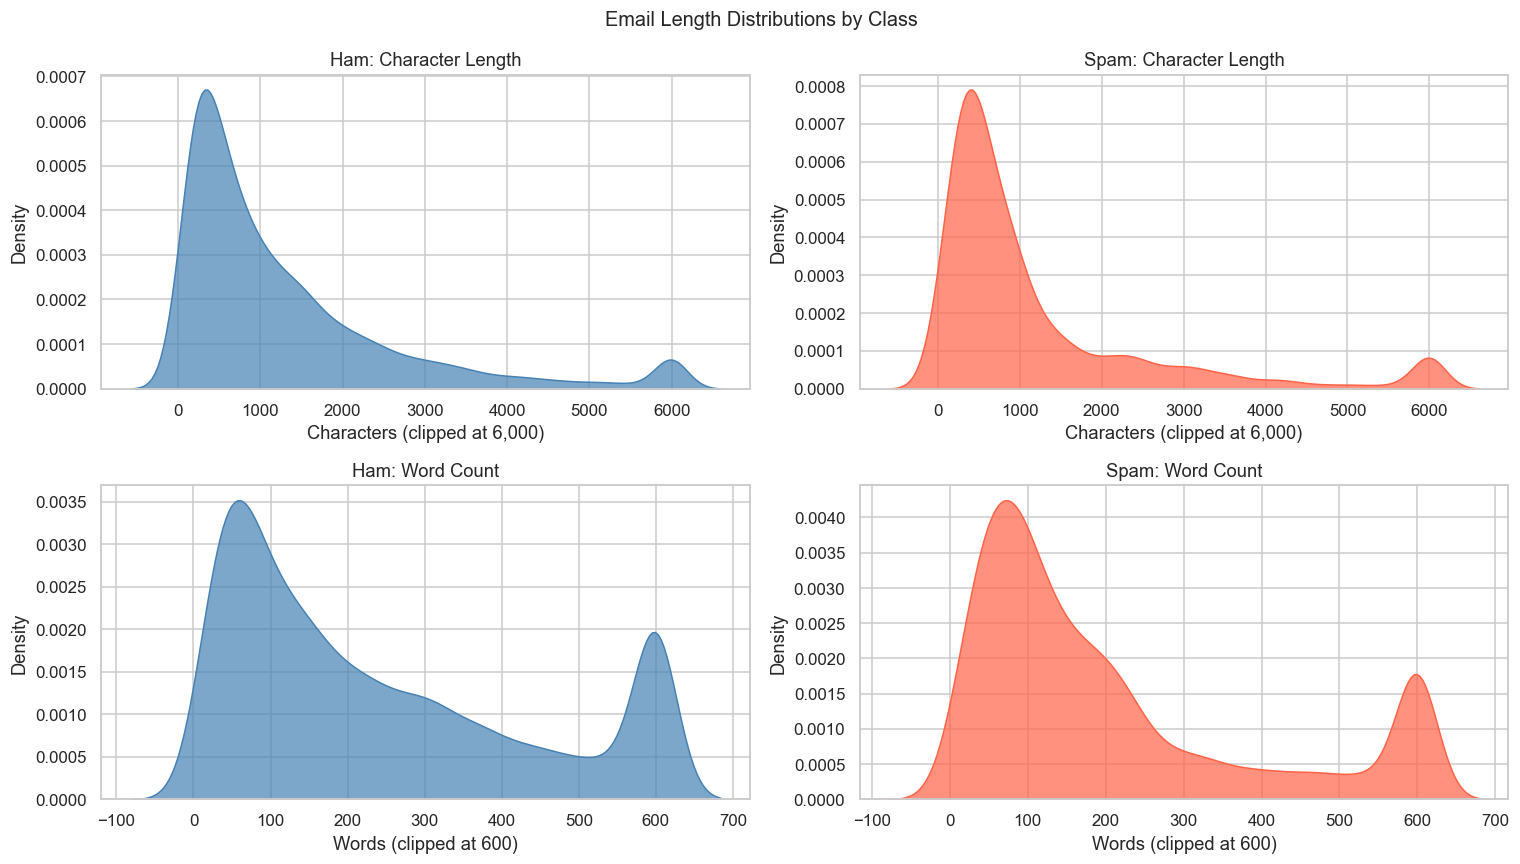

      char_len                                                       word_len                                                 
         count    mean     std   min    25%    50%     75%       max    count   mean     std  min   25%    50%    75%      max
label                                                                                                                         
0      16545.0  1717.4  5774.4  13.0  347.0  804.0  1705.0  228377.0  16545.0  362.8  1147.7  2.0  74.0  176.0  373.0  45451.0
1      17171.0  1319.2  1954.9   9.0  352.0  657.0  1382.5   28761.0  17171.0  262.3   386.5  1.0  72.0  138.0  275.0   8402.0

Saved -> reports/eda_text_length.png


In [4]:
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
label_map = {0: 'Ham', 1: 'Spam'}
colors = {0: 'steelblue', 1: 'tomato'}

for col_idx, label_int in enumerate([0, 1]):
    sub = df[df['label'] == label_int]
    name = label_map[label_int]
    c = colors[label_int]
    sns.kdeplot(sub['char_len'].clip(upper=6000), ax=axes[0, col_idx],
                fill=True, color=c, alpha=0.7)
    axes[0, col_idx].set_title(f'{name}: Character Length')
    axes[0, col_idx].set_xlabel('Characters (clipped at 6,000)')
    sns.kdeplot(sub['word_len'].clip(upper=600), ax=axes[1, col_idx],
                fill=True, color=c, alpha=0.7)
    axes[1, col_idx].set_title(f'{name}: Word Count')
    axes[1, col_idx].set_xlabel('Words (clipped at 600)')

plt.suptitle('Email Length Distributions by Class', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_text_length.png')
plt.show()
plt.close()

print(df.groupby('label')[['char_len', 'word_len']].describe().round(1).to_string())
print('\nSaved -> reports/eda_text_length.png')

## 3. Top Words per Class

*Applies `clean_text` (lowercase, URL/email replace, Porter stem) before counting.*

Vectorizing ~33k emails (stems each token - takes ~60s) ...


Vocabulary: 30,000 terms


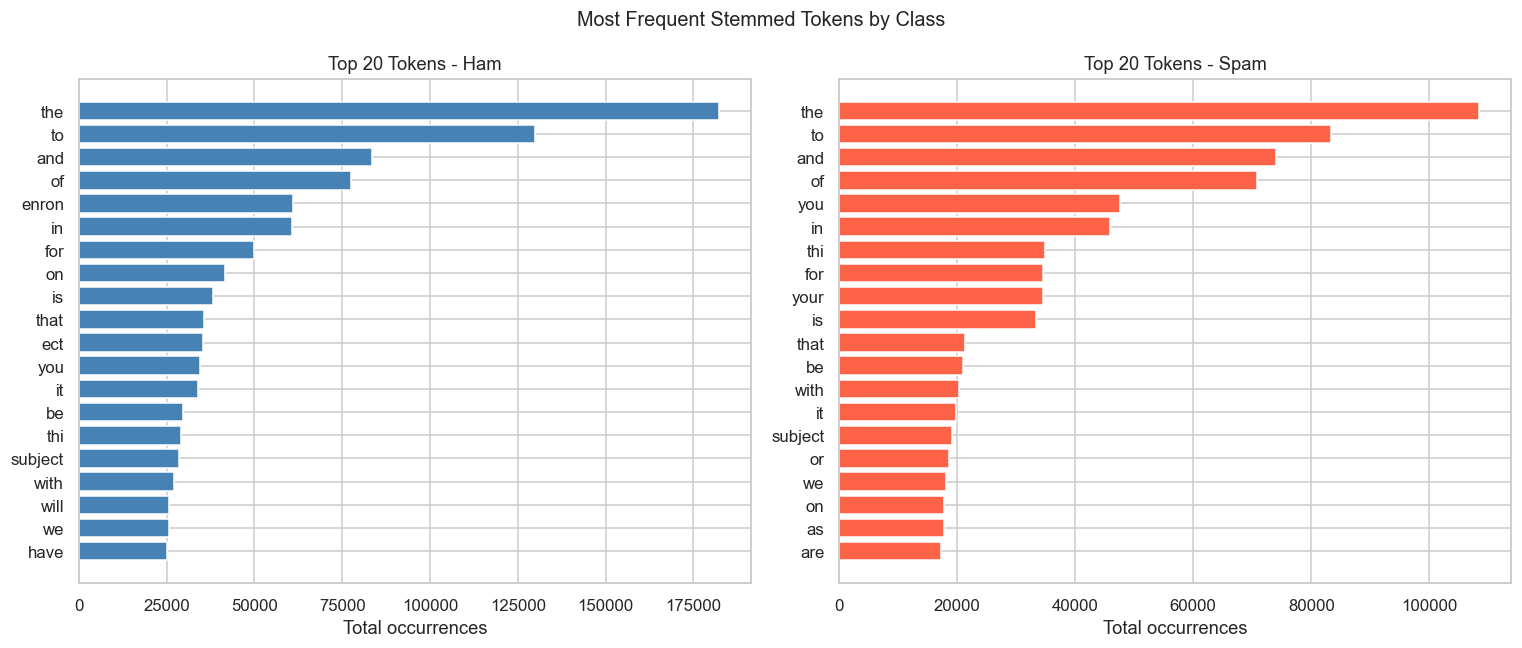

Saved -> reports/eda_top_words.png


In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from src.preprocessing import clean_text

print('Vectorizing ~33k emails (stems each token - takes ~60s) ...')
cv = CountVectorizer(preprocessor=clean_text, min_df=5, max_features=30_000)
X_counts = cv.fit_transform(df['text'])
feature_names = np.array(cv.get_feature_names_out())
print(f'Vocabulary: {len(feature_names):,} terms')

ham_freq  = np.asarray(X_counts[df['label'].values == 0].sum(axis=0)).flatten()
spam_freq = np.asarray(X_counts[df['label'].values == 1].sum(axis=0)).flatten()

N = 20
top_ham_idx  = ham_freq.argsort()[-N:][::-1]
top_spam_idx = spam_freq.argsort()[-N:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(feature_names[top_ham_idx][::-1], ham_freq[top_ham_idx][::-1],
             color='steelblue')
axes[0].set_title('Top 20 Tokens - Ham')
axes[0].set_xlabel('Total occurrences')
axes[1].barh(feature_names[top_spam_idx][::-1], spam_freq[top_spam_idx][::-1],
             color='tomato')
axes[1].set_title('Top 20 Tokens - Spam')
axes[1].set_xlabel('Total occurrences')

plt.suptitle('Most Frequent Stemmed Tokens by Class', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_top_words.png')
plt.show()
plt.close()
print('Saved -> reports/eda_top_words.png')

## 4. Word Clouds

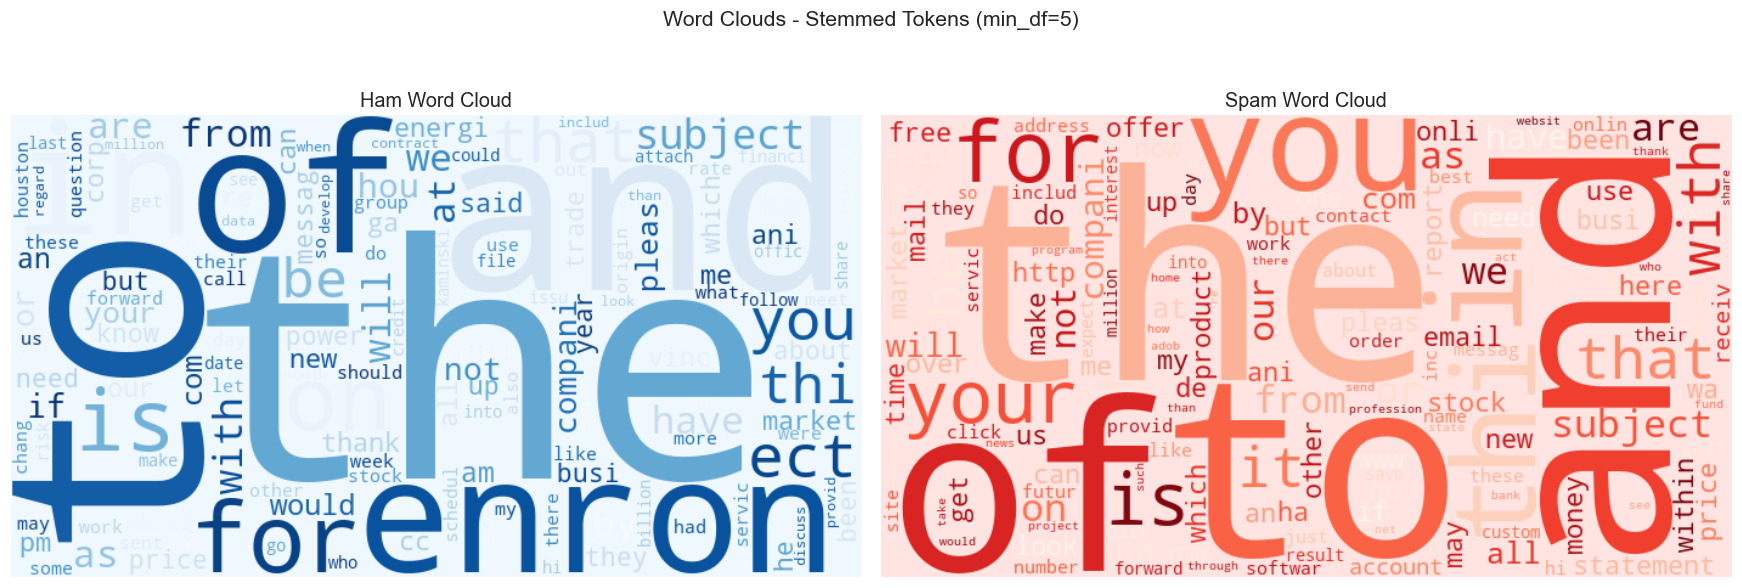

Saved -> reports/eda_wordclouds.png


In [6]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, freq_arr, title, cmap, bg in [
    (axes[0], ham_freq,  'Ham Word Cloud',  'Blues', 'aliceblue'),
    (axes[1], spam_freq, 'Spam Word Cloud', 'Reds',  'mistyrose'),
]:
    freq_dict = dict(zip(feature_names.tolist(), freq_arr.tolist()))
    wc = WordCloud(
        width=700, height=380, background_color=bg,
        colormap=cmap, max_words=150, prefer_horizontal=0.85,
    ).generate_from_frequencies(freq_dict)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.suptitle('Word Clouds - Stemmed Tokens (min_df=5)', fontsize=14)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_wordclouds.png')
plt.show()
plt.close()
print('Saved -> reports/eda_wordclouds.png')

## Summary

In [7]:
SEP = '=' * 54
print(SEP)
print('  EDA SUMMARY')
print(SEP)
print(f'  Total emails    : {len(df):,}')
print(f'  Ham  (label=0)  : {(df["label"]==0).sum():,}  ({(df["label"]==0).mean():.1%})')
print(f'  Spam (label=1)  : {(df["label"]==1).sum():,}  ({(df["label"]==1).mean():.1%})')
print(f'  Avg char length : {df["char_len"].mean():.0f}')
print(f'  Avg word count  : {df["word_len"].mean():.0f}')
print(f'  Vocabulary      : {len(feature_names):,} terms (min_df=5)')
print(f'  Figures saved   : {REPORTS_DIR}')
print(SEP)

  EDA SUMMARY
  Total emails    : 33,716
  Ham  (label=0)  : 16,545  (49.1%)
  Spam (label=1)  : 17,171  (50.9%)
  Avg char length : 1515
  Avg word count  : 312
  Vocabulary      : 30,000 terms (min_df=5)
  Figures saved   : C:\Users\akshi\Desktop\spam email\email-spam-classifier\reports
